<a href="https://colab.research.google.com/github/imdann06/diabetes-risk-prediction/blob/feature%2Fmodelo/fase-1/notebooks/01_diabetes_risk_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Partición Estratificada y Prevención de Data Leakage:

Se realiza una división estratificada del dataset (80% entrenamiento, 20% prueba) utilizando la variable objetivo Diabetes_Risk. La estratificación asegura que la    proporción de las clases (Low, Moderate, High) se mantenga intacta en ambos subconjuntos. Para garantizar la total ausencia de fuga de información (Data Leakage), todas las transformaciones de preprocesamiento se encadenan mediante un ColumnTransformer que ajusta sus parámetros (fit_transform) únicamente con X_train, aplicando posteriormente dicha transformación (transform) sobre X_test sin recalcular estadísticas.

2. Criterios para las Transformaciones Elegidas:

Imputación por Mediana (Variables Numéricas): Se opta por la mediana en lugar de la media para imputar los valores faltantes en las variables cuantitativas, debido a que la mediana es una medida de tendencia central robusta ante la presencia de datos atípicos (outliers) o distribuciones con sesgo.

Imputación por Moda (Variables Categóricas): Para las variables cualitativas con datos faltantes, se imputa con la moda (most frequent), preservando la categoría categórica de mayor prevalencia sin alterar la estructura cualitativa.

One-Hot Encoding (Variables Categóricas): Se transforma la información categórica no ordinal a una representación vectorial binaria (dummy). Se utiliza el parámetro handle_unknown='ignore' para prevenir errores en tiempo de inferencia ante categorías no observadas durante el entrenamiento en X_train.

Estandarización / StandardScaler (Variables Numéricas): Se escalan los atributos cuantitativos para que tengan una media de 0 y una desviación estándar de 1. Esto equipara la magnitud de todas las variables, previniendo que atributos con rangos numéricos elevados dominen de manera indebida sobre modelos sensibles a la escala (como regresión logística, máquinas de soporte vectorial o redes neuronales).

In [28]:
import zipfile
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

nombre_zip = 'diabetes_risk_prediction_dataset.zip.zip'

with zipfile.ZipFile(nombre_zip, 'r') as zip_ref:
    zip_ref.extractall('datos_descomprimidos') # Crea una carpeta con los datos
    print(" Archivo descompressión completada.")

# PASO 1: Cargar el CSV desde la carpeta extraída
df = pd.read_csv('datos_descomprimidos/diabetes_risk_prediction_dataset.csv')

# PASO 2: (División Train/Test sin Data Leakage)
X = df.drop(columns=['Diabetes_Risk'])
y = df['Diabetes_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n Dataset cargado y dividido exitosamente:")
print(f" Filas para entrenamiento (X_train): {X_train.shape[0]}")
print(f" Filas para prueba (X_test): {X_test.shape[0]}")

 Archivo descompressión completada.

 Dataset cargado y dividido exitosamente:
 Filas para entrenamiento (X_train): 40000
 Filas para prueba (X_test): 10000


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. VERIFICACIÓN Y SIMULACIÓN DE VALORES FALTANTES
nulos_existentes = X_train.isnull().sum().sum()

if nulos_existentes == 0:
    np.random.seed(42)
    n_samples = int(len(X_train) * 0.01)
    col_num = X_train.select_dtypes(include=[np.number]).columns[0]

    # Uso de .iloc para evitar la advertencia de pandas sobre copias
    idx_nan = np.random.choice(len(X_train), size=n_samples, replace=False)
    X_train.iloc[idx_nan, X_train.columns.get_loc(col_num)] = np.nan
    print(f"No se detectaron nulos. Se introdujo 1% de nulos controlados en '{col_num}'.")
else:
    print(f"El conjunto de entrenamiento ya contiene {nulos_existentes} valores faltantes reales.")
# 2. DEFINICIÓN DEL PIPELINE DE PREPROCESAMIENTO
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 3. TRANSFORMACIÓN SIN DATA LEAKAGE
# fit_transform SOLO en Train / transform SOLO en Test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("\n Preprocesamiento completado con éxito:")
print(f" Forma final de X_train procesado: {X_train_prep.shape}")
print(f" Forma final de X_test procesado: {X_test_prep.shape}")

El conjunto de entrenamiento ya contiene 16766 valores faltantes reales.

 Preprocesamiento completado con éxito:
 Forma final de X_train procesado: (40000, 105)
 Forma final de X_test procesado: (10000, 105)


# Diagnóstico, Exploración Inicial y Preprocesamiento de Datos
**Responsable:** Daniel  

En esta sección se realiza el diagnóstico de la calidad de los datos, la exploración estadística, la identificación de variables y la aplicación del pipeline de transformaciones e imputación.

#Exclusión de Columnas y Exploración Inicial

In [30]:
# Definición de la variable objetivo
TARGET = "Diabetes_Risk"

# Columnas excluidas para evitar sesgos o target leakage
columnas_excluir = [
    "Patient_ID",
    "Diabetes_Risk_Score",
    "AI_Health_Recommendation",
    "Doctor_Consultation_Needed"
]
columnas_excluir = [col for col in columnas_excluir if col in df.columns]

# Separación de características (X) y variable objetivo (y)
X = df.drop(columns=[TARGET] + columnas_excluir)
y = df[TARGET]

print("Variable objetivo:", TARGET)
print("Columnas excluidas de X:", columnas_excluir)
print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Exploración de las primeras filas
print("\nPrimeras 5 filas de X:")
display(X.head())

Variable objetivo: Diabetes_Risk
Columnas excluidas de X: ['Patient_ID', 'Diabetes_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed']

Dimensiones de X: (50000, 36)
Dimensiones de y: (50000,)

Primeras 5 filas de X:


,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Alcohol_Consumption,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,Never,Yes,No,Yes,Yes,No,Good,Retired,Rural,4.4
1,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,199.3,...,Frequently,Yes,No,Yes,Yes,Yes,Average,Government,Rural,2.1
2,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,219.6,...,Frequently,Yes,No,No,Yes,No,Average,Government,Urban,2.8
3,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,217.7,...,Occasionally,Yes,Yes,No,No,No,Average,Business,Rural,1.5
4,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,153.5,...,Occasionally,No,Yes,Yes,Yes,Yes,Poor,Private,Rural,1.6


#Diagnóstico de Faltantes, Duplicados y Target

In [31]:
# 1. Diagnóstico de duplicados
duplicados = df.duplicated().sum()
print("Registros duplicados en el dataset:", duplicados)

# 2. Diagnóstico detallado de valores faltantes
faltantes = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean() * 100).round(2)
}).sort_values(by="Valores faltantes", ascending=False)

print("\nReporte de valores faltantes:")
display(faltantes[faltantes["Valores faltantes"] > 0])
print("Total general de valores nulos:", int(df.isnull().sum().sum()))

# 3. Distribución y porcentaje de la variable objetivo
print("\nDistribución de la variable objetivo (Diabetes_Risk):")
dist_df = pd.DataFrame({
    "Cantidad": y.value_counts(),
    "Porcentaje (%)": (y.value_counts(normalize=True) * 100).round(2)
})
display(dist_df)

Registros duplicados en el dataset: 0

Reporte de valores faltantes:


,Valores faltantes,Porcentaje (%)
Weight_kg,2962,5.92
Height_cm,2945,5.89
Sleep_Hours,2017,4.03
Exercise_Hours_Per_Week,1992,3.98
HbA1c,1974,3.95
Daily_Walking_Minutes,1964,3.93
HDL,1000,2.00
LDL,1000,2.00
Triglycerides,1000,2.00
Medication_Adherence,1000,2.00


Total general de valores nulos: 20810

Distribución de la variable objetivo (Diabetes_Risk):


,Cantidad,Porcentaje (%)
Diabetes_Risk,,
High,36593,73.19
Moderate,12937,25.87
Low,470,0.94


#Identificación de Tipos y Divisón Train/Test Estratificada

In [32]:
# Identificación automática de variables numéricas y categóricas
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"VARIABLES NUMÉRICAS ({len(numeric_features)}):")
print(numeric_features)

print(f"\nVARIABLES CATEGÓRICAS ({len(categorical_features)}):")
print(categorical_features)

# Divisió estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nDatos de Entrenamiento: {X_train.shape}")
print(f"Datos de Prueba:        {X_test.shape}")

VARIABLES NUMÉRICAS (20):
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours', 'Daily_Water_Intake_L']

VARIABLES CATEGÓRICAS (16):
['Gender', 'Country', 'Physical_Activity_Level', 'Diet_Quality', 'Sugar_Intake_Level', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type']

Datos de Entrenamiento: (40000, 36)
Datos de Prueba:        (10000, 36)


#Construcción del Preprocesador y Aplicación

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib

# Pipeline para variables numéricas (Imputación por mediana + StandardScaler)
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas (Imputación por moda + OneHotEncoder)
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Integración en ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# Ajuste SOLO en Train / Transformación en Train y Test (Evita Data Leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocesamiento ejecutado con éxito:")
print("Forma de X_train procesado:", X_train_processed.shape)
print("Forma de X_test procesado: ", X_test_processed.shape)

Preprocesamiento ejecutado con éxito:
Forma de X_train procesado: (40000, 86)
Forma de X_test procesado:  (10000, 86)


#Reconstrucción de DataFrames, Comprobaciones y Guardado

In [34]:
# 1. Recuperación de nombres de columnas
feature_names = preprocessor.get_feature_names_out()

# 2. Creación de DataFrames estructurados
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

# 3. Verificación de nulos y escalamiento
print("=== COMPROBACIONES DE CALIDAD ===")
print("Valores NaN en X_train procesado:", np.isnan(X_train_processed).sum())
print("Valores NaN en X_test procesado: ", np.isnan(X_test_processed).sum())

# Comprobar media ~ 0 y std ~ 1 en numéricas
scaled_columns = [col for col in X_train_processed_df.columns if col.startswith("num__")]
print("\nComprobación del escalamiento (Muestra de variables numéricas):")
display(X_train_processed_df[scaled_columns].agg(["mean", "std"]).T.head(5))

# 4. Creación de Datasets finales con Target
train_final = X_train_processed_df.copy()
train_final[TARGET] = y_train.values

test_final = X_test_processed_df.copy()
test_final[TARGET] = y_test.values

# 5. Guardar archivos locales para la sección de Salo
train_final.to_csv("train_preprocesado.csv", index=False)
test_final.to_csv("test_preprocesado.csv", index=False)
joblib.dump(preprocessor, "preprocesador_diabetes.pkl")

print("\n Artefactos generados para la fase de modelado:")
print(" - train_preprocesado.csv")
print(" - test_preprocesado.csv")
print(" - preprocesador_diabetes.pkl")

=== COMPROBACIONES DE CALIDAD ===
Valores NaN en X_train procesado: 0
Valores NaN en X_test procesado:  0

Comprobación del escalamiento (Muestra de variables numéricas):


,mean,std
num__Age,-1.469935e-16,1.000013
num__Height_cm,1.519673e-15,1.000013
num__Weight_kg,-4.579448e-16,1.000013
num__BMI,8.313350e-17,1.000013
num__Waist_Circumference_cm,6.240342e-16,1.000013



 Artefactos generados para la fase de modelado:
 - train_preprocesado.csv
 - test_preprocesado.csv
 - preprocesador_diabetes.pkl


---
# Sección de Modelado y Evaluación
**Responsable:** Salo  

En las siguientes celdas se procede con la carga de los artefactos preprocesados, el entrenamiento del clasificador Baseline (`DummyClassifier`), el modelo principal (`RandomForestClassifier`), la evaluación mediante matriz de confusión y el guardado del `Pipeline` final.
---

modelado

In [35]:
import os
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

In [36]:
#cargo lo datos ya preprocesados
train_df = pd.read_csv("train_preprocesado.csv")
test_df = pd.read_csv("test_preprocesado.csv")

X_train = train_df.drop(columns=["Diabetes_Risk"])
y_train = train_df["Diabetes_Risk"]
X_test = test_df.drop(columns=["Diabetes_Risk"])
y_test = test_df["Diabetes_Risk"]

#aquí se guarda
preprocesador = joblib.load("preprocesador_diabetes.pkl")

Accuracy: 0.7319
F1-score macro: 0.2817



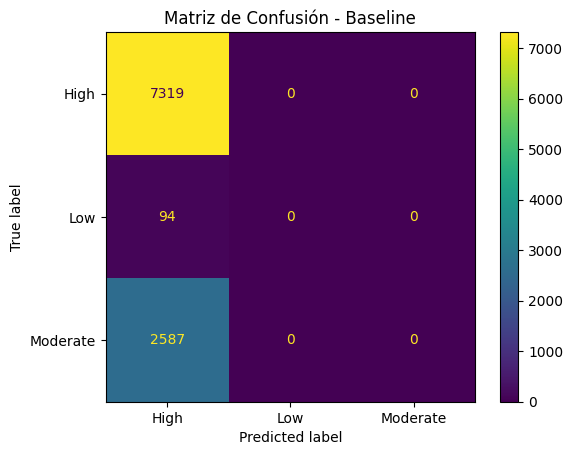

In [37]:
#baseline

#entrenamiento

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

#calculo de las metricas

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")


print(f"Accuracy: {acc_baseline:.4f}")
print(f"F1-score macro: {f1_baseline:.4f}\n")

#construcción de matriz de confusion
conf_matrix_baseline = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(conf_matrix_baseline, display_labels=baseline.classes_).plot()
plt.title("Matriz de Confusión - Baseline")
plt.show()

Accuracy: 0.8966
F1-score macro: 0.5699

              precision    recall  f1-score   support

        High       0.89      0.99      0.94      7319
         Low       0.00      0.00      0.00        94
    Moderate       0.90      0.67      0.77      2587

    accuracy                           0.90     10000
   macro avg       0.60      0.55      0.57     10000
weighted avg       0.89      0.90      0.89     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


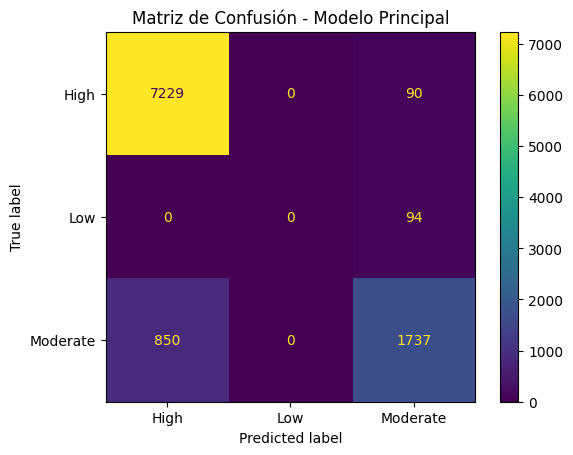

In [38]:
# Moldelo elegido Random forest

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred_modelo = modelo.predict(X_test)

#calculo de métricas
acc_modelo = accuracy_score(y_test, y_pred_modelo)
f1_modelo = f1_score(y_test, y_pred_modelo, average="macro")

print(f"Accuracy: {acc_modelo:.4f}")
print(f"F1-score macro: {f1_modelo:.4f}\n")
print(classification_report(y_test, y_pred_modelo))

#construcción matriz
conf_matrix_modelo = confusion_matrix(y_test, y_pred_modelo)
ConfusionMatrixDisplay(conf_matrix_modelo, display_labels=modelo.classes_).plot()
plt.title("Matriz de Confusión - Modelo Principal")
plt.show()

In [39]:
# comparación entre ambas

print(f"F1 macro baseline: {f1_baseline:.4f}")
print(f"F1 macro modelo:   {f1_modelo:.4f}")
print(f"Mejora sobre el baseline: {f1_modelo - f1_baseline:+.4f}")

F1 macro baseline: 0.2817
F1 macro modelo:   0.5699
Mejora sobre el baseline: +0.2881


In [40]:
#el pipeline completo (preprocesamiento + modelo entrenado)

pipeline_final = Pipeline([
    ("preprocesador", preprocesador),
    ("classifier", modelo),
])

os.makedirs("fase-1", exist_ok=True)
joblib.dump(pipeline_final, "fase-1/modelo.joblib", compress=3)
print("\nPipeline final guardado en fase-1/modelo.joblib")


Pipeline final guardado en fase-1/modelo.joblib


In [41]:
# prueba
import pandas as pd
import joblib



df_original = pd.read_csv("datos_descomprimidos/diabetes_risk_prediction_dataset.csv")


X_raw_sample = df_original.drop(columns=["Diabetes_Risk"]).sample(5, random_state=1)
y_real = df_original.loc[X_raw_sample.index, "Diabetes_Risk"]


pipeline_cargado = joblib.load("fase-1/modelo.joblib")


predicciones = pipeline_cargado.predict(X_raw_sample)

print("Predicciones:", predicciones)
print("Valores reales:", list(y_real))

Predicciones: ['High' 'High' 'High' 'High' 'Moderate']
Valores reales: ['High', 'High', 'High', 'High', 'Moderate']


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
